In [1]:
import sys, argparse
import pickle, json
import os

import numpy as np
import matplotlib.pyplot as plt
import glob


from defiant import OptimalStatistic
from defiant.extra import mdc1_utils
from la_forge.core import Core
import healpy as hp

import libstempo as T
import libstempo.plot as LP, libstempo.toasim as LT
import enterprise.signals.parameter as parameter
from enterprise.signals import white_signals
from enterprise.signals import utils
from enterprise.signals import gp_signals
from enterprise.signals import signal_base

from enterprise.pulsar import Pulsar, Tempo2Pulsar

import PTA_utils

from maps.anis_pta import anis_pta
from maps.utils import *

ModuleNotFoundError: No module named 'defiant'

In [3]:
datapath = "psrE2/final"

par_dir = os.path.join(datapath, "par")

tim_dir = os.path.join(datapath, "tim")

parfiles = sorted(glob.glob(os.path.join(par_dir, "*.par")))

if len(parfiles) == 0:

    raise FileNotFoundError(f"No .par files found in {par_dir}")

psrs = []

for parfile in parfiles:

    name = os.path.splitext(os.path.basename(parfile))[0]

    timfile = os.path.join(tim_dir, name + ".tim")

    if not os.path.exists(timfile):

        print(f"Skipping {name}: no matching .tim file")

        continue

    print(f"Loading {name}")

    psr = T.tempopulsar(

        parfile=parfile,

        timfile=timfile,

    )

    psrs.append(psr)

Npsr = len(psrs)

if Npsr < 2:

    raise ValueError(f"Need at least 2 pulsars, loaded {Npsr}")

print(f"Loaded {Npsr} pulsars from {datapath}")

Loading J0
Loading J1
Loading J10
Loading J100
Loading J101
Loading J102
Loading J103
Loading J104
Loading J105
Loading J106
Loading J107
Loading J108
Loading J109
Loading J11
Loading J110
Loading J111
Loading J112
Loading J113
Loading J114
Loading J115
Loading J116
Loading J117
Loading J118
Loading J119
Loading J12
Loading J120
Loading J121
Loading J122
Loading J123
Loading J124
Loading J125
Loading J126
Loading J127
Loading J128
Loading J129
Loading J13
Loading J130
Loading J131
Loading J132
Loading J133
Loading J134
Loading J135
Loading J136
Loading J137
Loading J138
Loading J139
Loading J14
Loading J140
Loading J141
Loading J142
Loading J143
Loading J144
Loading J145
Loading J146
Loading J147
Loading J148
Loading J149
Loading J15
Loading J16
Loading J17
Loading J18
Loading J19
Loading J2
Loading J20
Loading J21
Loading J22
Loading J23
Loading J24
Loading J25
Loading J26
Loading J27
Loading J28
Loading J29
Loading J3
Loading J30
Loading J31
Loading J32
Loading J33
Loading J34
Loadin

In [4]:
parfiles = sorted(glob.glob(os.path.join(datapath, "par", "*.par")))
timfiles = sorted(glob.glob(os.path.join(datapath, "tim", "*.tim")))

PSRs = []

for p, t in zip(parfiles, timfiles):
    psr = Pulsar(p, t)
    PSRs.append(psr)


#for psr in psrs:
#    PSRs.append(Tempo2Pulsar(psr))

#print(f"Converted {len(PSRs)} pulsars to enterprise Pulsar objects")

1.8817333265037495
4.246312612691918


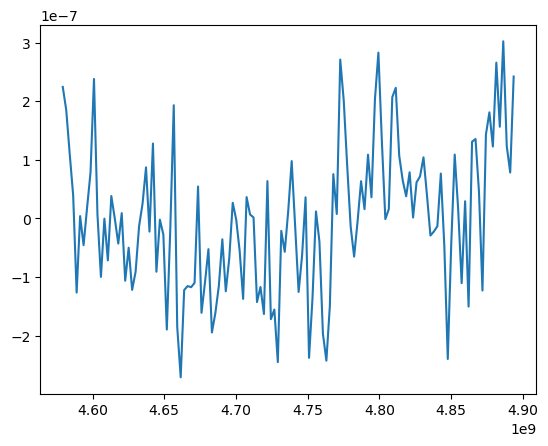

In [15]:
print(PSRs[3].theta)
print(PSRs[3].phi)
plt.plot(PSRs[3].stoas, PSRs[3].residuals)

## Creating a dataset

## Building sky map from the OS results